In [2]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

[[  0   1   2 ... 253 254 255]
 [  0   1   2 ... 253 254 255]
 [  0   1   2 ... 253 254 255]
 ...
 [  0   1   2 ... 253 254 255]
 [  0   1   2 ... 253 254 255]
 [  0   1   2 ... 253 254 255]]
[[  0   0   0 ...   0   0   0]
 [  1   1   1 ...   1   1   1]
 [  2   2   2 ...   2   2   2]
 ...
 [253 253 253 ... 253 253 253]
 [254 254 254 ... 254 254 254]
 [255 255 255 ... 255 255 255]]
[[-128 -127 -126 ...  125  126  127]
 [-128 -127 -126 ...  125  126  127]
 [-128 -127 -126 ...  125  126  127]
 ...
 [-128 -127 -126 ...  125  126  127]
 [-128 -127 -126 ...  125  126  127]
 [-128 -127 -126 ...  125  126  127]]
[[-128 -128 -128 ... -128 -128 -128]
 [-127 -127 -127 ... -127 -127 -127]
 [-126 -126 -126 ... -126 -126 -126]
 ...
 [ 125  125  125 ...  125  125  125]
 [ 126  126  126 ...  126  126  126]
 [ 127  127  127 ...  127  127  127]]


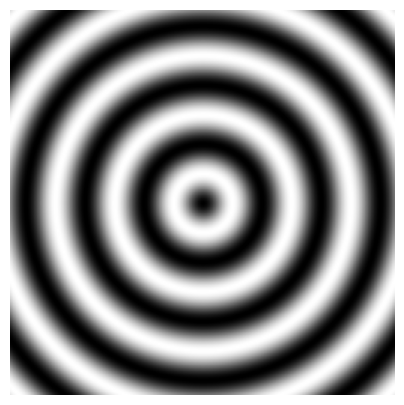

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

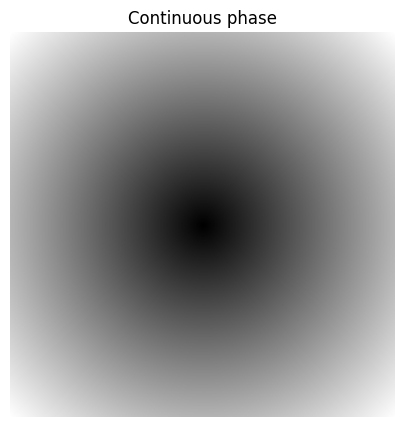

In [3]:
H, W = 256, 256

yy, xx = np.mgrid[:H, :W]
cx, cy = W // 2, H // 2
X = xx - cx
Y = yy - cy


def add_spiral_phase(psi, points, polarities):
    # points: list of (y,x); polarities: +1 for termination, -1 for bifurcation (convention)
    H, W = psi.shape
    Y, X = np.mgrid[:H, :W]
    out = psi.copy()
    for (yy, xx), p in zip(points, polarities):
        out += p * np.arctan2(Y - yy, X - xx)
    return out


print(xx)
print(yy)

print(X)
print(Y)

# radial phase
kappa = 0.16  # controls spacing of rings (ridges)
psi_c = kappa * np.sqrt(X * X + Y * Y)
original_phase = psi_c.copy()

psi_s = add_spiral_phase(psi_c, points=[(200, 256)], polarities=[+1])

# render ridges (dark)
I = 0.5 * (1.0 - np.cos(psi_c))
img = (I * 255).astype(np.uint8)

plt.figure(figsize=(5, 5))
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

plt.figure(figsize=(5, 5))
plt.title("Continuous phase")
plt.imshow(psi_c, cmap="gray")
plt.axis("off")


In [4]:
import numpy as np
from collections import deque


def phase_integration_feng_jain(
    Gcx_block: np.ndarray, Gcy_block: np.ndarray, block_size=8
) -> np.ndarray:
    H, W = Gcx_block.shape  # Block dimensions (H rows, W columns of blocks)
    I_H, I_W = H * block_size, W * block_size  # Image dimensions

    P = np.full((H, W), np.nan)  # Phase offset P(m,n): initialize as unknown
    reconstructed_mask = np.zeros((H, W), dtype=bool)

    # Initialize the final phase image
    Psi_C = np.zeros((I_H, I_W), dtype=float)

    # 1. Initialize Queue and Starting Block (Flood-Fill Setup)
    m_start, n_start = 0, 0
    if Gcx_block.size == 0:
        return Psi_C

    queue = deque([(m_start, n_start)])
    P[m_start, n_start] = 0.0  # Assume phase offset of the first block is 0 [cite: 354]
    reconstructed_mask[m_start, n_start] = True

    # Pre-calculate coordinate matrices for the block model (Eq. 14)
    # X_local and Y_local are 8x8 matrices of pixel coordinates within a block (0 to 7)
    X_local, Y_local = np.meshgrid(np.arange(block_size), np.arange(block_size))

    # 2. Iterative Phase Reconstruction (Flood-Fill)
    while queue:
        m_curr, n_curr = queue.popleft()  # Current (reconstructed) block coordinates

        # Iterate over 4-connected neighbors
        for dm, dn in [(0, 1), (0, -1), (1, 0), (-1, 0)]:
            m_neigh, n_neigh = m_curr + dm, n_curr + dn

            # Check bounds and if the neighbor is in the foreground/unreconstructed
            if (
                0 <= m_neigh < H
                and 0 <= n_neigh < W
                and not reconstructed_mask[m_neigh, n_neigh]
            ):

                # --- A. Define Border and Estimate Phase Offset P(m_neigh, n_neigh) ---

                phase_candidates = (
                    []
                )  # List to hold phase offsets (psi) estimated at border pixels

                # Current block's phase P_curr
                P_curr = P[m_curr, n_curr]

                # Determine border coordinates and fixed axis (x= or y=)
                if dm == 0 and dn == 1:  # Right neighbor (Border: x = n_curr*8 + 7)
                    x_pix = n_curr * block_size + block_size - 1
                    y_range = np.arange(m_curr * block_size, (m_curr + 1) * block_size)
                    fixed_axis = "x"
                elif dm == 0 and dn == -1:  # Left neighbor (Border: x = n_curr*8)
                    x_pix = n_curr * block_size
                    y_range = np.arange(m_curr * block_size, (m_curr + 1) * block_size)
                    fixed_axis = "x"
                elif dm == 1 and dn == 0:  # Down neighbor (Border: y = m_curr*8 + 7)
                    y_pix = m_curr * block_size + block_size - 1
                    x_range = np.arange(n_curr * block_size, (n_curr + 1) * block_size)
                    fixed_axis = "y"
                elif dm == -1 and dn == 0:  # Up neighbor (Border: y = m_curr*8)
                    y_pix = m_curr * block_size
                    x_range = np.arange(n_curr * block_size, (n_curr + 1) * block_size)
                    fixed_axis = "y"
                else:
                    continue  # Should not happen

                # Iterate over border pixels to collect phase offsets
                if fixed_axis == "x":
                    for y in y_range:
                        x = x_pix
                        # Calculate phase of current block at (x, y) [cite: 362]
                        psi_curr = (
                            Gcx_block[m_curr, n_curr] * x
                            + Gcy_block[m_curr, n_curr] * y
                            + P_curr
                        )

                        # Calculate the part of the neighbor's phase model NOT including P_neigh
                        # Note: Gcx/Gcy for the neighbor is used here [cite: 362]
                        gradient_contribution_neigh = (
                            Gcx_block[m_neigh, n_neigh] * x
                            + Gcy_block[m_neigh, n_neigh] * y
                        )

                        # The phase offset candidate is: P_neigh = psi_curr - gradient_contribution_neigh
                        phase_candidates.append(psi_curr - gradient_contribution_neigh)
                elif fixed_axis == "y":
                    for x in x_range:
                        y = y_pix
                        psi_curr = (
                            Gcx_block[m_curr, n_curr] * x
                            + Gcy_block[m_curr, n_curr] * y
                            + P_curr
                        )
                        gradient_contribution_neigh = (
                            Gcx_block[m_neigh, n_neigh] * x
                            + Gcy_block[m_neigh, n_neigh] * y
                        )
                        phase_candidates.append(psi_curr - gradient_contribution_neigh)

                # Convert phase offsets to complex numbers, average, and convert back
                complex_candidates = np.exp(1j * np.array(phase_candidates))
                complex_mean = np.mean(complex_candidates)
                P_new = np.arctan2(complex_mean.imag, complex_mean.real)

                # --- B. Update and Propagate ---
                P[m_neigh, n_neigh] = P_new
                reconstructed_mask[m_neigh, n_neigh] = True
                queue.append((m_neigh, n_neigh))

    # 3. Generate Final Continuous Phase Image Psi_C (Pixel-Level Fill)
    for m in range(H):
        for n in range(W):
            if reconstructed_mask[m, n]:
                # Get block's model parameters
                Gcx = Gcx_block[m, n]
                Gcy = Gcy_block[m, n]
                P_offset = P[m, n]

                # Calculate pixel coordinates (global) for the 8x8 block
                x_start, y_start = n * block_size, m * block_size
                X_global = X_local + x_start
                Y_global = Y_local + y_start

                # Apply the piecewise planar model: Psi_C = Gcx*x + Gcy*y + P(m,n)
                Psi_C[
                    y_start : y_start + block_size, x_start : x_start + block_size
                ] = (Gcx * X_global + Gcy * Y_global + P_offset)

    return Psi_C

<Figure size 640x480 with 0 Axes>

<Figure size 800x400 with 0 Axes>

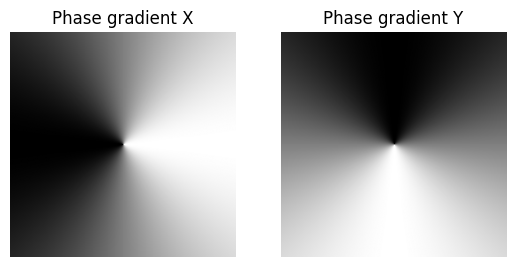

In [5]:
# phase derivation
phase_grad_x = np.gradient(psi_c, axis = 1)
phase_grad_y = np.gradient(psi_c, axis = 0)

plt.figure()
plt.figure(figsize=(8, 4))
plt.subplots(1, 2)

plt.subplot(1, 2, 1)
plt.imshow(phase_grad_x, cmap="gray")
plt.axis("off")
plt.title("Phase gradient X")

plt.subplot(1, 2, 2)
plt.imshow(phase_grad_y, cmap="gray")
plt.axis("off")
plt.title("Phase gradient Y")
plt.show()

In [6]:
reassembled_phase = phase_integration_feng_jain(phase_grad_x, phase_grad_y, block_size=1)

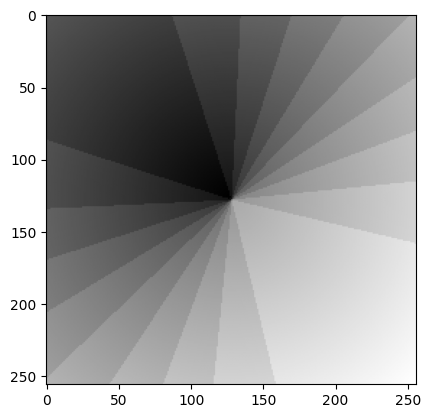

In [ ]:
# render ridges (dark)
I_reassembled = 0.5 * (1.0 - np.cos(reassembled_phase))
img_reassembled = (I_reassembled * 255).astype(np.uint8)

plt.figure()
plt.figure(figsize=(8, 4))
plt.subplots(1, 2)

plt.subplot(1, 2, 1)
plt.imshow(reassembled_phase, cmap="gray")
plt.axis("off")
plt.title("Reassembled Phase")

plt.subplot(1, 2, 2)
plt.imshow(img_reassembled, cmap="gray")
plt.axis("off")
plt.title("Reassembled Image")
plt.show()

<Figure size 640x480 with 0 Axes>

<Figure size 800x400 with 0 Axes>

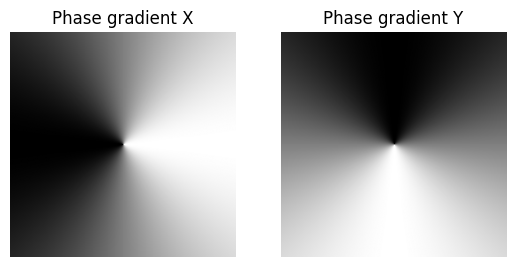

In [8]:
# phase derivation
phase_grad_intgd_x = np.gradient(reassembled_phase, axis=1)
phase_grad_intgd_y = np.gradient(reassembled_phase, axis=0)

plt.figure()
plt.figure(figsize=(8, 4))
plt.subplots(1, 2)

plt.subplot(1, 2, 1)
plt.imshow(phase_grad_x, cmap="gray")
plt.axis("off")
plt.title("Phase gradient X")

plt.subplot(1, 2, 2)
plt.imshow(phase_grad_y, cmap="gray")
plt.axis("off")
plt.title("Phase gradient Y")
plt.show()